# Healthy Diet & Calorie Intake Analysis

## Project Overview
This project analyzes dietary and health records of **6,000 individuals** to understand how calorie intake, BMI, macronutrients, water intake, activity level, diet type, and health status are connected.

## DataSet Information

1. Person_ID : Unique identifier for each individual (e.g. P0001). Not a predictive feature.

2. Age : Age of the individual in years across multiple life stages.

3. Gender: Gender of the individual — Male, Female, or Other.

4. Height_cm: Height measured in centimeters. Used to calculate BMI.

5. Weight_kg: Body weight in kilograms. Key metric for health assessment.

6. BMI: Body Mass Index = weight(kg) / height(m)². Indicates Healthy, Overweight, Obese or Underweight.

7. Activity_Level: Physical activity level — Sedentary, Lightly Active, Moderately Active, Very Active, Athlete.

8. Daily_Calorie_Requirement: Recommended daily calorie intake based on age, gender, weight, height and activity level (TDEE).

9. Daily_Calorie_Consumed: Actual daily calories consumed. Compare with Daily_Calorie_Requirement to find calorie surplus or deficit.

10. Protein_Intake_g: Daily protein intake in grams. Varies across diet types, especially High Protein and Vegan diets.

11. Carbohydrate_Intake_g: Daily carbohydrate intake in grams. Notably low in Keto diet followers.

12. Fat_Intake_g: Daily fat intake in grams. Higher in Keto and Mediterranean diet types.

13. Water_Intake_Liters: Daily water consumption in liters. Important for metabolism and overall health.

14. Diet_Type: Dietary pattern followed — Keto, Vegan, Balanced, Mediterranean, High Protein, Vegetarian.

15. Health_Status: Target variable — Health classification of the individual. Categories: Healthy, Overweight, Obese, Underweight. Use as label for classification models.

## Problem Statement:

Maintaining a healthy lifestyle depends on a balance between nutrition, physical activity, and overall health. However, individuals often differ in their calorie intake, nutrient consumption, hydration levels, BMI, and activity levels, making it difficult to understand how these factors are related.

The objective of this project is to perform an Exploratory Data Analysis (EDA) on a health and nutrition dataset to identify patterns, relationships, and trends among dietary habits, body composition, physical activity, and health status. The analysis aims to uncover insights into how factors such as calorie intake, protein consumption, water intake, and activity levels are associated with BMI and overall health.

The findings from this analysis can help support data-driven decisions for nutrition planning, health monitoring, and lifestyle improvement.
    

## 1. Importing  Libraries and Setting Chart Style

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Chart styling
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

In [2]:
def format_plot(title, xlabel=None, ylabel=None, rotation=0):
    """consistent formatting to all charts."""
    plt.title(title, fontsize=16, fontweight="bold", pad=15)
    if xlabel:
        plt.xlabel(xlabel)
    if ylabel:
        plt.ylabel(ylabel)
    plt.xticks(rotation=rotation)
    plt.grid(alpha=0.3)
    plt.tight_layout()


def add_bar_labels(ax):
    """Value labels on bar charts."""
    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f", padding=3)
    return ax

## 2. Load Dataset

In [3]:
data = pd.read_csv("healthy_diet_calorie_intake.csv")
data.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


In [4]:
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")

Rows: 6000
Columns: 15


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Person_ID                  6000 non-null   object 
 1   Age                        6000 non-null   int64  
 2   Gender                     6000 non-null   object 
 3   Height_cm                  6000 non-null   float64
 4   Weight_kg                  6000 non-null   float64
 5   BMI                        6000 non-null   float64
 6   Activity_Level             6000 non-null   object 
 7   Daily_Calorie_Requirement  6000 non-null   int64  
 8   Daily_Calorie_Consumed     6000 non-null   int64  
 9   Protein_Intake_g           6000 non-null   float64
 10  Carbohydrate_Intake_g      6000 non-null   float64
 11  Fat_Intake_g               6000 non-null   float64
 12  Water_Intake_Liters        6000 non-null   float64
 13  Diet_Type                  6000 non-null   objec

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6000.0,48.817167,18.141837,18.0,33.0,48.00,65.000,80.0
Height_cm,6000.0,168.592533,9.160213,145.0,161.7,168.20,175.200,198.6
Weight_kg,6000.0,74.070933,12.417877,40.0,65.5,74.10,82.700,116.6
BMI,6000.0,26.094300,4.162643,12.9,23.3,26.00,28.900,44.0
Daily_Calorie_Requirement,6000.0,2286.223833,469.541134,1223.0,1941.0,2232.50,2581.250,4079.0
Daily_Calorie_Consumed,6000.0,2490.520333,602.279679,1000.0,2057.0,2433.00,2859.000,5158.0
Protein_Intake_g,6000.0,123.773150,61.999158,17.4,78.8,108.90,155.100,457.5
Carbohydrate_Intake_g,6000.0,288.035317,123.914738,-23.6,229.1,297.15,366.125,729.7
Fat_Intake_g,6000.0,93.698417,43.953993,23.2,65.9,82.30,105.100,341.7
Water_Intake_Liters,6000.0,2.734917,0.681486,1.5,2.2,2.60,3.100,5.0


## 3. Data Quality Check

Checking data for missing values, duplicates, and invalid values.

In [7]:
missing_values = data.isnull().sum().sort_values(ascending=False)
missing_values

Person_ID                    0
Age                          0
Gender                       0
Height_cm                    0
Weight_kg                    0
BMI                          0
Activity_Level               0
Daily_Calorie_Requirement    0
Daily_Calorie_Consumed       0
Protein_Intake_g             0
Carbohydrate_Intake_g        0
Fat_Intake_g                 0
Water_Intake_Liters          0
Diet_Type                    0
Health_Status                0
dtype: int64

In [8]:
duplicate_count = data.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [9]:
# Checking negative values in numeric nutrition columns
nutrition_cols = ["Daily_Calorie_Requirement", "Daily_Calorie_Consumed", 
                  "Protein_Intake_g", "Carbohydrate_Intake_g", "Fat_Intake_g", 
                  "Water_Intake_Liters"]

negative_values = (data[nutrition_cols] < 0).sum()
negative_values

Daily_Calorie_Requirement     0
Daily_Calorie_Consumed        0
Protein_Intake_g              0
Carbohydrate_Intake_g        54
Fat_Intake_g                  0
Water_Intake_Liters           0
dtype: int64

### Data Quality Observation
- The dataset contains **6,000 rows and 15 columns**.
- No missing values were found in the original dataset.
- No duplicate records were identified, suggesting that each row represents a unique participant.


## 4. Data Cleaning and Feature Engineering

In [10]:
# Creating a copy to preserve original data
df = data.copy()

# Replace invalid negative nutrition values with NaN, then fill using median
for col in nutrition_cols:
    df.loc[df[col] < 0, col] = np.nan
    df[col] = df[col].fillna(df[col].median())

# Calorie balance: positive means consumed more calories than required
df["Calorie_Balance"] = df["Daily_Calorie_Consumed"] - df["Daily_Calorie_Requirement"]

# Calorie balance category
df["Calorie_Balance_Category"] = np.where(
    df["Calorie_Balance"] > 0, "Surplus", "Deficit / Balanced"
)

# BMI category based on common BMI ranges
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Healthy"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

# Age group for better segmentation
def age_group(age):
    if age < 30:
        return "18-29"
    elif age < 45:
        return "30-44"
    elif age < 60:
        return "45-59"
    else:
        return "60+"

df["BMI_Category"] = df["BMI"].apply(bmi_category)
df["Age_Group"] = df["Age"].apply(age_group)

df[["Age", "Age_Group", "BMI", "BMI_Category", "Daily_Calorie_Requirement", 
    "Daily_Calorie_Consumed", "Calorie_Balance", "Calorie_Balance_Category"]].head()

,Age,Age_Group,BMI,BMI_Category,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Calorie_Balance,Calorie_Balance_Category
0,50,45-59,24.0,Healthy,2852.0,2625.0,-227.0,Deficit / Balanced
1,18,18-29,26.9,Overweight,1904.0,2044.0,140.0,Surplus
2,68,60+,33.3,Obese,2009.0,2540.0,531.0,Surplus
3,22,18-29,23.3,Healthy,2318.0,2096.0,-222.0,Deficit / Balanced
4,30,30-44,23.5,Healthy,2144.0,1937.0,-207.0,Deficit / Balanced


# Exploratory Data Analysis and Visual Insights

## 5. Age Distribution

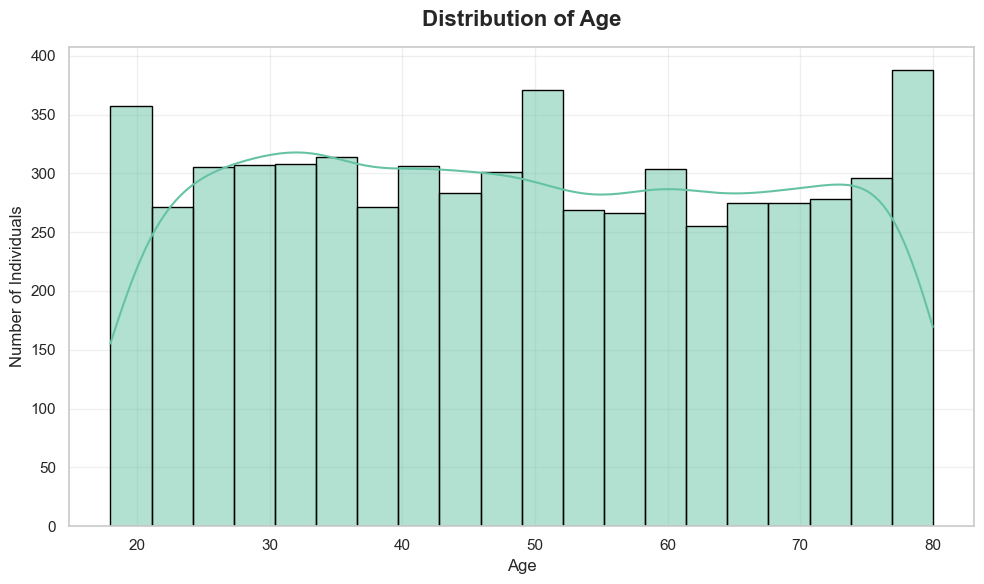

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Age"], bins=20, kde=True, edgecolor="black")
format_plot("Distribution of Age", "Age", "Number of Individuals")
plt.show()

**Observation:** The dataset includes participants across a broad age range, with a fairly even distribution and no significant concentration in any particular age group.

## 6. Gender Distribution

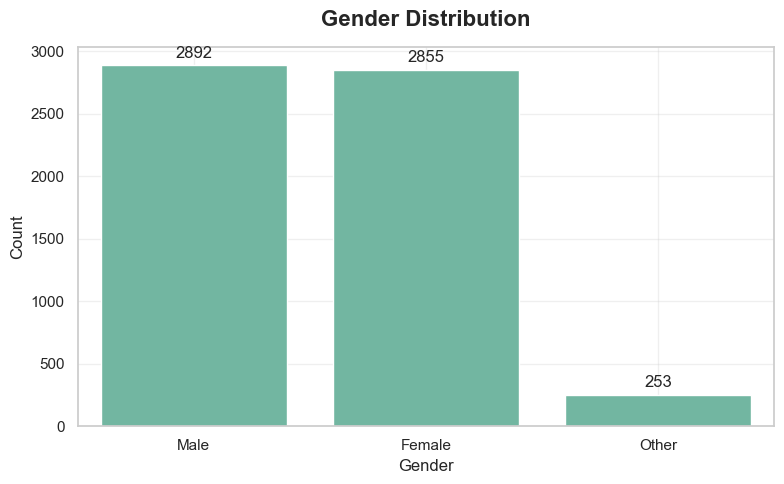

In [12]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="Gender", data=df, order=df["Gender"].value_counts().index)
add_bar_labels(ax)
format_plot("Gender Distribution", "Gender", "Count")
plt.show()

**Observation:** The dataset has a nearly equal number of male and female participants. This balanced distribution makes it suitable for comparing health and dietary patterns across both genders.

## 7. BMI Category Distribution

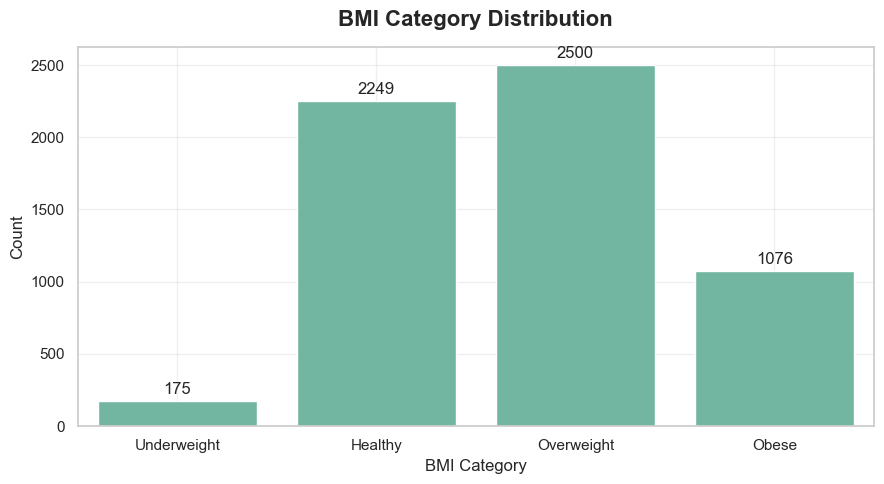

In [13]:
plt.figure(figsize=(9, 5))
bmi_order = ["Underweight", "Healthy", "Overweight", "Obese"]
ax = sns.countplot(x="BMI_Category", data=df, order=bmi_order)
add_bar_labels(ax)
format_plot("BMI Category Distribution", "BMI Category", "Count")
plt.savefig("bmi_category_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

**Observation:** The Overweight category has the highest number of participants, followed by the Healthy group. The Underweight category is the least represented, suggesting that higher BMI categories are more common in this dataset.

## 8. BMI Distribution by Health Status

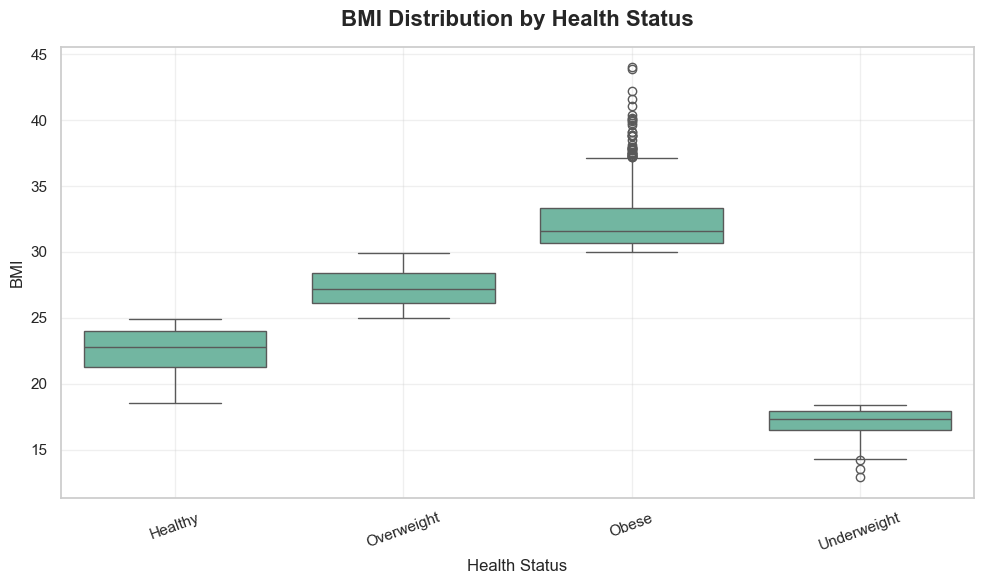

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Health_Status", y="BMI", data=df)
format_plot("BMI Distribution by Health Status", "Health Status", "BMI", rotation=20)
plt.show()

**Observation:** BMI differs across the health status groups, with higher BMI values concentrated in the Overweight and Obese categories. A few outliers are also present, indicating variation within each group.

## 9. Activity Level Distribution

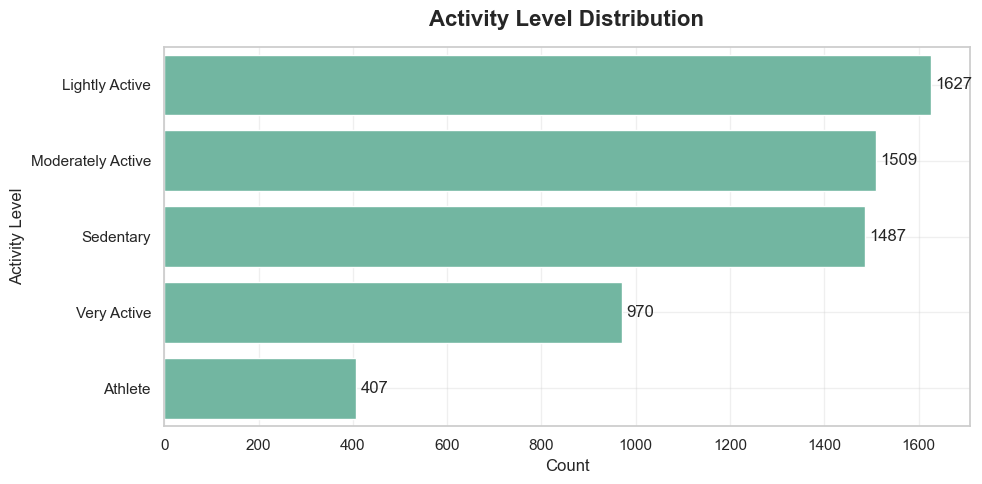

In [15]:
plt.figure(figsize=(10, 5))
activity_order = df["Activity_Level"].value_counts().index
ax = sns.countplot(y="Activity_Level", data=df, order=activity_order)
add_bar_labels(ax)
format_plot("Activity Level Distribution", "Count", "Activity Level")
plt.show()

**Observation:** Participants are distributed across different activity levels, with each category having a reasonable number of individuals. This balanced distribution allows for meaningful comparisons between physical activity, calorie intake, and BMI.

## 10. Average Calories Consumed by Gender

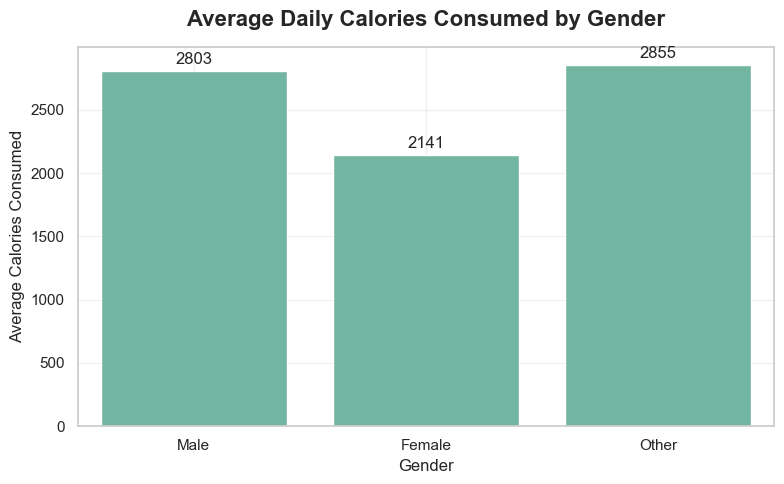

In [16]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="Gender", y="Daily_Calorie_Consumed", data=df, estimator="mean", errorbar=None)
add_bar_labels(ax)
format_plot("Average Daily Calories Consumed by Gender", "Gender", "Average Calories Consumed")
plt.show()

**Observation:** The average calorie intake is nearly the same for both genders, indicating that male and female participants have similar overall dietary consumption in this dataset.

## 11. Calorie Requirement vs Consumption

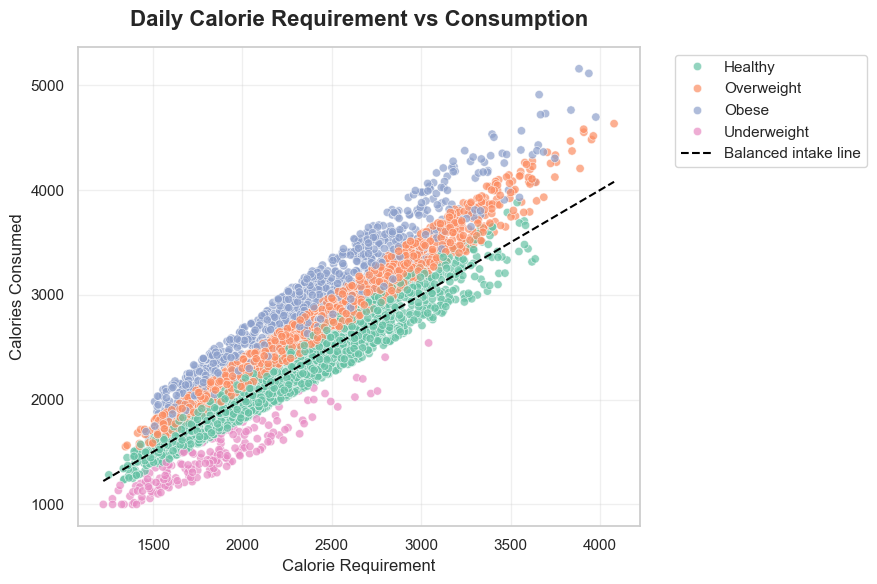

In [17]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    x="Daily_Calorie_Requirement",
    y="Daily_Calorie_Consumed",
    hue="Health_Status",
    data=df,
    alpha=0.7
)
plt.plot(
    [df["Daily_Calorie_Requirement"].min(), df["Daily_Calorie_Requirement"].max()],
    [df["Daily_Calorie_Requirement"].min(), df["Daily_Calorie_Requirement"].max()],
    linestyle="--",
    color="black",
    label="Balanced intake line"
)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
format_plot("Daily Calorie Requirement vs Consumption", "Calorie Requirement", "Calories Consumed")
plt.savefig("daily_calorie_requirement_vs_consumption.png",
            dpi=300,
            bbox_inches="tight")
plt.show()
plt.show()

**Observation:** The chart shows a mix of participants in both calorie surplus and calorie deficit. This variation highlights differences in daily energy balance, which may influence changes in body weight and BMI over time.

## 12. Calorie Balance by Health Status

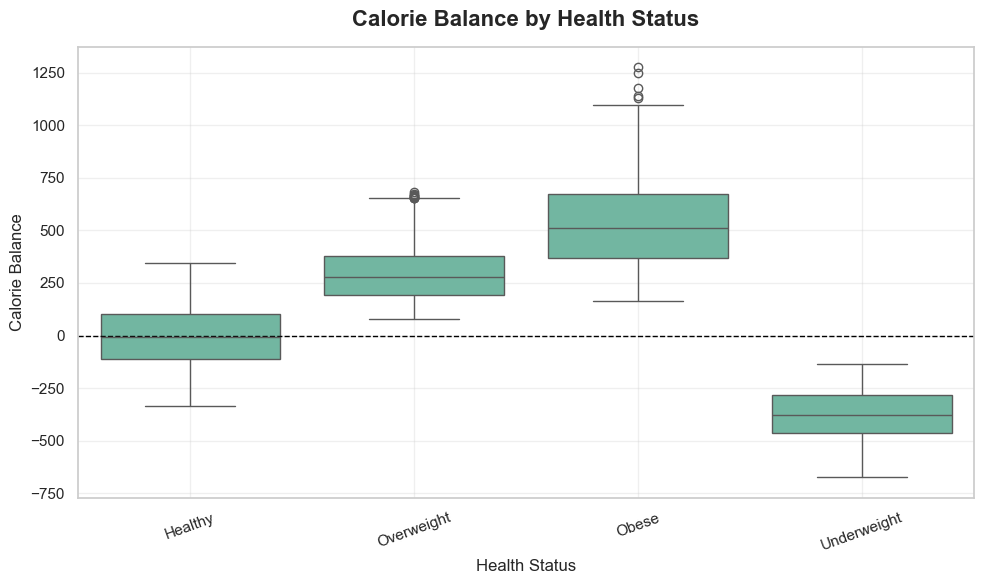

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Health_Status", y="Calorie_Balance", data=df)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
format_plot("Calorie Balance by Health Status", "Health Status", "Calorie Balance", rotation=20)
plt.show()

**Observation:** The average calorie balance varies across different health status groups, indicating that some groups are more likely to consume excess calories than others.

## 13. Calories Consumed by Activity Level

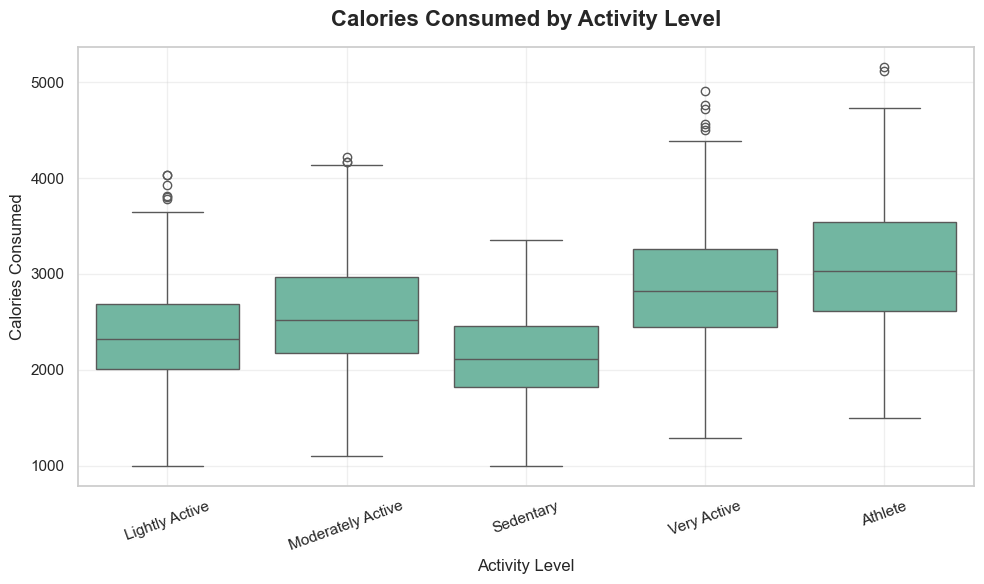

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Activity_Level", y="Daily_Calorie_Consumed", data=df, order=activity_order)
format_plot("Calories Consumed by Activity Level", "Activity Level", "Calories Consumed", rotation=20)
plt.show()

**Observation:** Calorie intake varies across different activity levels. Participants with higher activity levels generally tend to consume more calories, although a few outliers are present within each group.

## 14. Water Intake by Activity Level

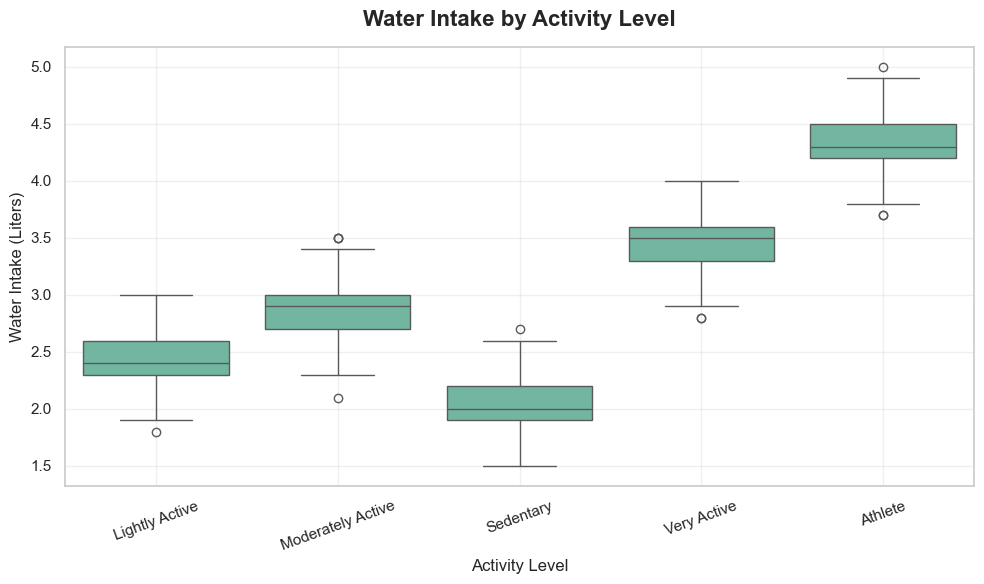

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Activity_Level", y="Water_Intake_Liters", data=df, order=activity_order)
format_plot("Water Intake by Activity Level", "Activity Level", "Water Intake (Liters)", rotation=20)
plt.show()

**Observation:** Participants with higher activity levels tend to have higher water intake, suggesting that hydration increases as physical activity becomes more intense.

## 15. Average Protein Intake by Activity Level

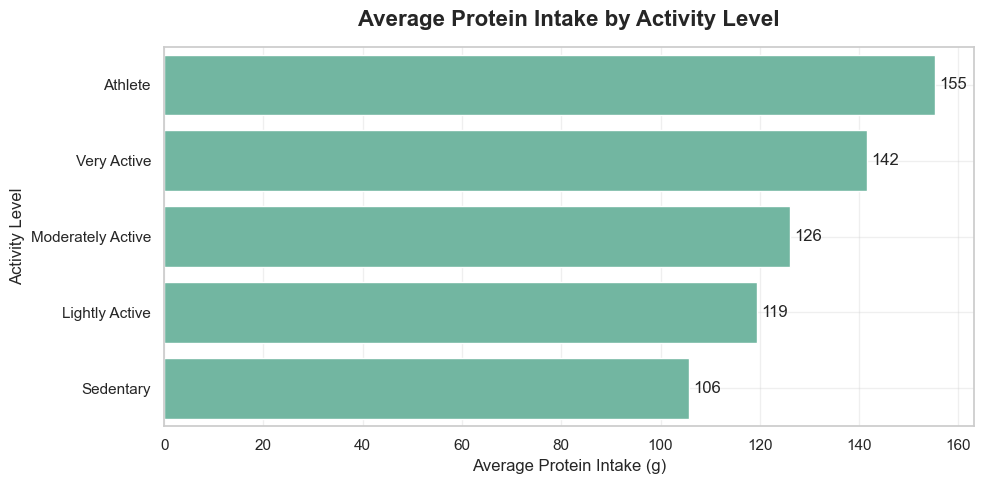

In [21]:
plt.figure(figsize=(10, 5))
protein_by_activity = (
    df.groupby("Activity_Level")["Protein_Intake_g"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
ax = sns.barplot(x="Protein_Intake_g", y="Activity_Level", data=protein_by_activity)
add_bar_labels(ax)
format_plot("Average Protein Intake by Activity Level", "Average Protein Intake (g)", "Activity Level")
plt.show()

**Observation:** Protein intake increases as activity level increases, suggesting that more active individuals consume additional protein to support energy needs and muscle recovery.

## 16. Health Status Distribution

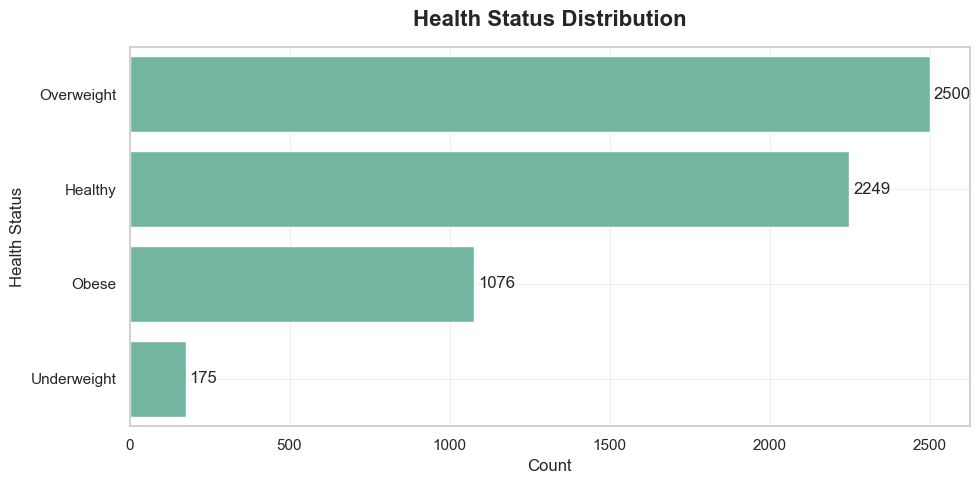

In [22]:
plt.figure(figsize=(10, 5))
health_order = df["Health_Status"].value_counts().index
ax = sns.countplot(y="Health_Status", data=df, order=health_order)
add_bar_labels(ax)
format_plot("Health Status Distribution", "Count", "Health Status")
plt.show()

**Observation:** The dataset includes participants across multiple health status categories, providing a balanced view for analyzing how dietary habits and lifestyle factors vary among different health groups.

## 18. BMI vs Calories Consumed

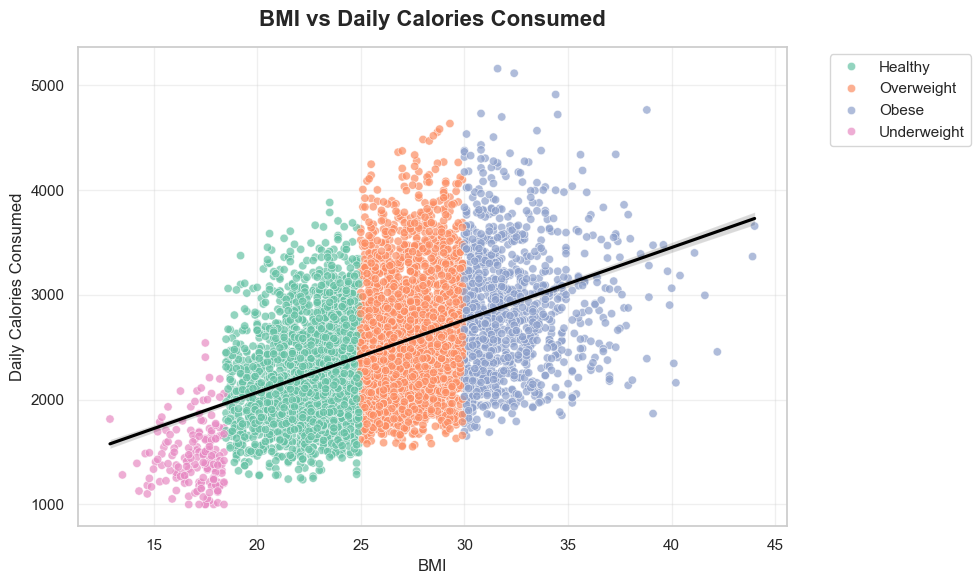

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="BMI", y="Daily_Calorie_Consumed", hue="Health_Status", data=df, alpha=0.7)
sns.regplot(x="BMI", y="Daily_Calorie_Consumed", data=df, scatter=False, color="black")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
format_plot("BMI vs Daily Calories Consumed", "BMI", "Daily Calories Consumed")
plt.show()

**Observation:** A positive trend is observed between BMI and calorie intake, indicating that participants with higher BMI generally tend to consume more calories. However, the variation in the data suggests that other lifestyle factors may also influence BMI.

## 19. Macronutrient Relationship Heatmap

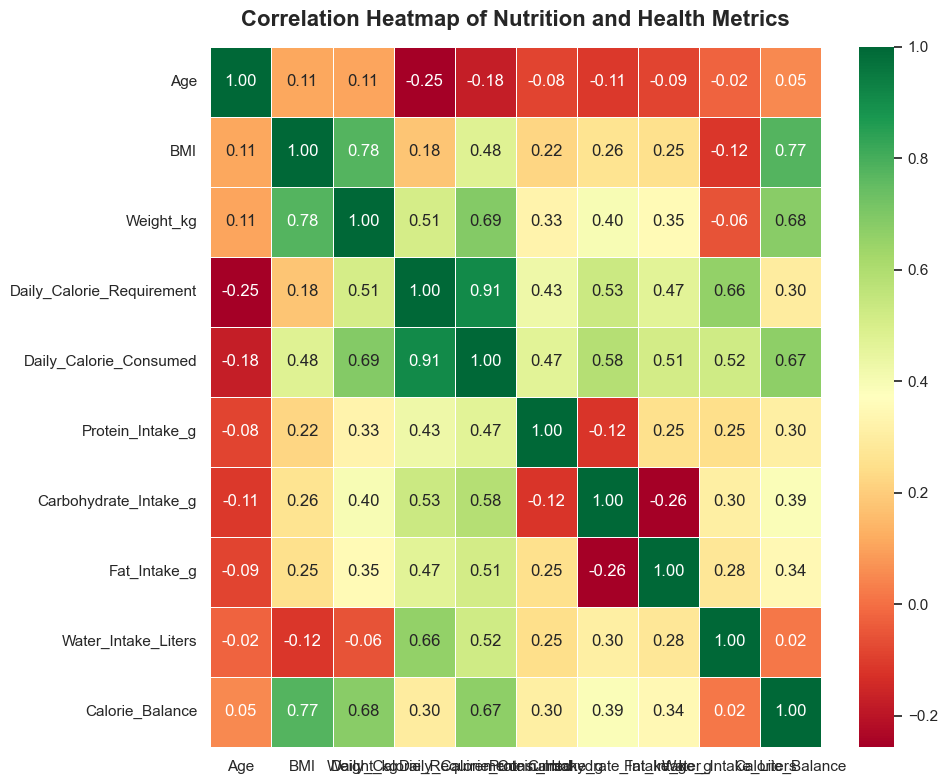

In [24]:
plt.figure(figsize=(10, 8))
selected_corr_cols = [
    "Age", "BMI", "Weight_kg", "Daily_Calorie_Requirement", "Daily_Calorie_Consumed",
    "Protein_Intake_g", "Carbohydrate_Intake_g", "Fat_Intake_g", "Water_Intake_Liters",
    "Calorie_Balance"
]

corr = df[selected_corr_cols].corr()
sns.heatmap(corr, annot=True, cmap="RdYlGn", linewidths=0.5, fmt=".2f")
format_plot("Correlation Heatmap of Nutrition and Health Metrics")

plt.savefig("heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Observation:** Strong positive correlations are observed between calorie requirement and calorie consumption, as well as between BMI, weight, and calorie balance. Most other variables show weak to moderate relationships, suggesting that only a few factors are strongly associated.

## 20. Pairplot for Key Health Metrics

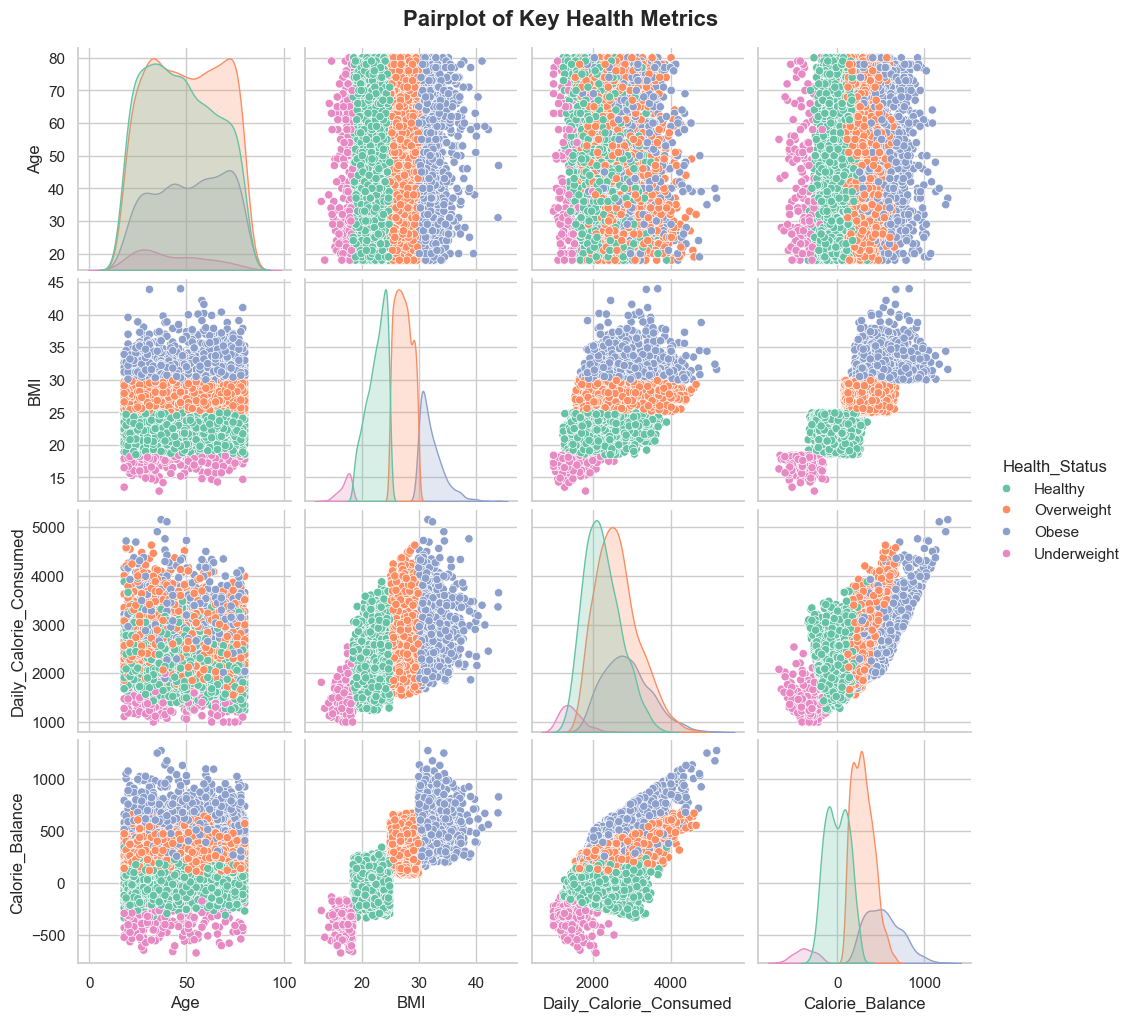

In [25]:
selected_features = ["Age", "BMI", "Daily_Calorie_Consumed", "Calorie_Balance", "Health_Status"]
sns.pairplot(df[selected_features], hue="Health_Status", diag_kind="kde")
plt.suptitle("Pairplot of Key Health Metrics", y=1.02, fontsize=16, fontweight="bold")

plt.savefig("pairplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Observation:** The pairplot reveals clear differences among the health status groups, especially in terms of BMI and calorie balance. A positive relationship is also observed between daily calorie consumption and calorie balance, while age shows relatively little variation across the groups.

## Health Summary

In [26]:
health_summary = (
    df.groupby("Health_Status")
    .agg(
        records=("Person_ID", "count"),
        avg_bmi=("BMI", "mean"),
        avg_calorie_required=("Daily_Calorie_Requirement", "mean"),
        avg_calorie_consumed=("Daily_Calorie_Consumed", "mean"),
        avg_calorie_balance=("Calorie_Balance", "mean"),
        avg_water_intake=("Water_Intake_Liters", "mean")
    )
    .round(2)
    .sort_values("records", ascending=False)
)

health_summary

,records,avg_bmi,avg_calorie_required,avg_calorie_consumed,avg_calorie_balance,avg_water_intake
Health_Status,,,,,,
Overweight,2500,27.29,2330.58,2622.56,291.98,2.72
Healthy,2249,22.52,2249.10,2244.66,-4.44,2.86
Obese,1076,32.26,2334.29,2865.74,531.45,2.54
Underweight,175,17.03,1834.03,1456.74,-377.29,2.56


In [27]:
activity_health_pct = (
    pd.crosstab(df["Activity_Level"], df["Health_Status"], normalize="index") * 100
).round(1)

activity_health_pct

Health_Status,Healthy,Obese,Overweight,Underweight
Activity_Level,,,,
Athlete,53.8,9.8,34.2,2.2
Lightly Active,33.9,16.7,46.7,2.8
Moderately Active,44.8,12.7,40.2,2.4
Sedentary,23.1,31.5,41.6,3.8
Very Active,47.3,10.8,38.9,3.0


# Conclusion & Key Findings:

Final Insights
1. The dataset is clean and well-structured, with no missing or duplicate values, making it suitable for reliable exploratory data analysis.
2. BMI, calorie balance, and daily calorie consumption show strong relationships, indicating that energy intake and expenditure play an important role in overall health status.
3. Participants with higher activity levels generally consume more calories, protein, and water, suggesting that dietary intake tends to increase with physical activity.
4. The correlation heatmap and pairplot reveal meaningful patterns, particularly between BMI, calorie balance, weight, and calorie consumption, while age shows relatively weak relationships with the other variables.
5. Health status groups exhibit distinct differences in BMI and calorie balance, making these features valuable for understanding variations in nutritional and lifestyle patterns.


## Future Scope

This project can be extended by:

- Building machine learning models to predict BMI or health status.
- Developing personalized nutrition recommendations.
- Creating an interactive Tableau or Power BI dashboard.
- Identifying key lifestyle factors that influence calorie balance and overall health.